Output RMS noise (signal band): 27877.81 µV
Input-referred RMS noise: 27877.81 nA
Total system output noise: 27878.57 µV


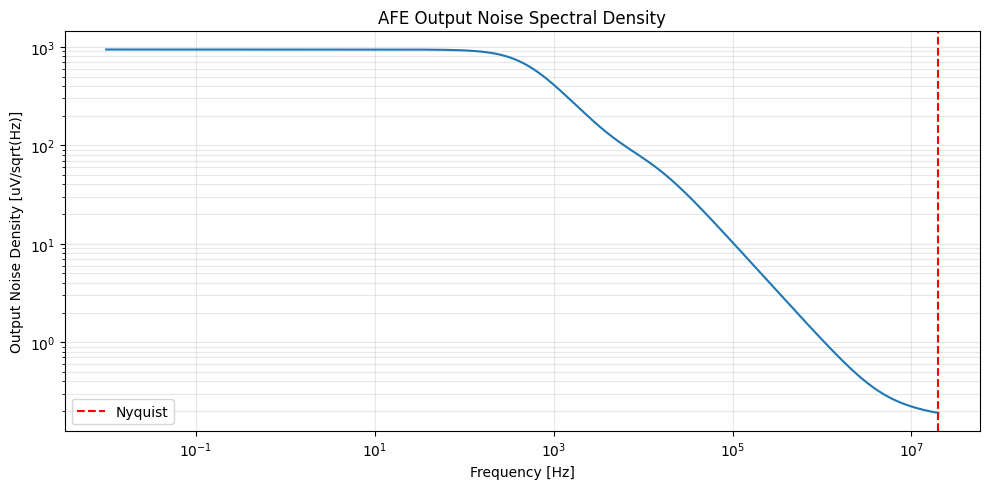

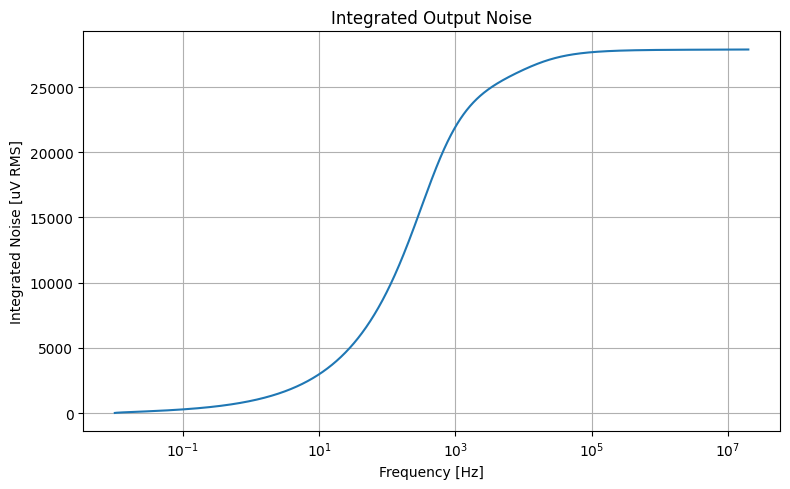

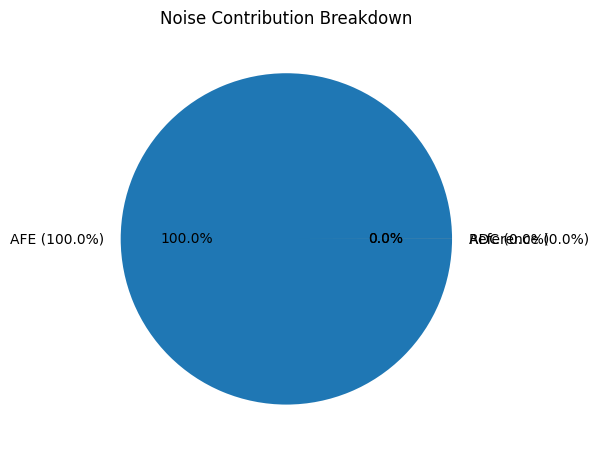


========== NOISE BUDGET ==========
Bandwidth:           0 – 20 MHz
AFE output noise:    27877.81 µV rms
ADC noise:           200.00 µV rms
Reference noise:     50.00 µV rms
Total system noise:  27878.57 µV rms
Input-referred:      27877.81 nA rms


In [1]:

from PyLTSpice import RawRead
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================
# Reports Directory
# ============================================
report_root = "./Reports"
os.makedirs(report_root, exist_ok=True)


raw_path = '/workspace/Hardware/DesignVerification/CircuitModels/AFE/TbNoise.raw'
raw = RawRead(raw_path)


freq = raw.get_trace('frequency').get_wave(0)
onoise = np.abs(raw.get_trace('V(onoise)').get_wave(0))

# ============================================
# Define System Bandwidth
# ============================================
f_low = 0      # 0 Hz
f_high = 20e6  # 20 MHz

mask = (freq >= f_low) & (freq <= f_high)
freq_band = freq[mask]
onoise_band = onoise[mask]

# ============================================
# Integrate Noise Numerically
# ============================================
output_noise_rms = np.sqrt(np.trapezoid(onoise_band**2, freq_band))
print(f"Output RMS noise (signal band): {output_noise_rms*1e6:.2f} µV")

# ============================================
# Convert to Input-Referred Noise
# ============================================
Rf = 1e3  # TIA feedback resistor
input_noise_rms = output_noise_rms / Rf
print(f"Input-referred RMS noise: {input_noise_rms*1e9:.2f} nA")

# ============================================
# Add Additional Noise Sources
# ============================================
# Datasheet values (example — replace with real numbers)
adc_noise_vrms = 200e-6      # ADC input noise
ref_noise_vrms = 50e-6       # Reference noise at output
sipm_shot_noise_vrms = 0     # Add if known

total_output_noise = np.sqrt(
    output_noise_rms**2 +
    adc_noise_vrms**2 +
    ref_noise_vrms**2 +
    sipm_shot_noise_vrms**2
)
print(f"Total system output noise: {total_output_noise*1e6:.2f} µV")

# ============================================
# PLOT — Noise Spectral Density
# ============================================
plt.figure(figsize=(10, 5))
plt.loglog(freq, onoise * 1e6)
plt.axvline(f_high, color='r', linestyle='--', label='Nyquist')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Output Noise Density [uV/sqrt(Hz)]')
plt.title('AFE Output Noise Spectral Density')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(report_root, "AfeOutputNoiseSpectralDensity.svg"),
            format="svg")

plt.show()

cumulative = np.sqrt(np.cumsum(onoise_band**2 * np.gradient(freq_band)))

# ============================================
# PLOT — Cumulative Integrated Noise
# ============================================

plt.figure(figsize=(8, 5))
plt.semilogx(freq_band, cumulative * 1e6)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Integrated Noise [uV RMS]")
plt.title("Integrated Output Noise")
plt.grid(True, which="both")
plt.tight_layout()

plt.savefig(os.path.join(report_root, "IntegratedOutputNoise.svg"),
            format="svg")

plt.show()

# ============================================
# PLOT — Noise Contribution Breakdown (Pie)
# ============================================

# Variance contributions (must use squared values)
var_afe = output_noise_rms**2
var_adc = adc_noise_vrms**2
var_ref = ref_noise_vrms**2

var_total = var_afe + var_adc + var_ref

percentages = [
    100 * var_afe / var_total,
    100 * var_adc / var_total,
    100 * var_ref / var_total
]

labels = [
    f"AFE ({percentages[0]:.1f}%)",
    f"ADC ({percentages[1]:.1f}%)",
    f"Reference ({percentages[2]:.1f}%)"
]

plt.figure(figsize=(6, 6))
plt.pie(percentages, labels=labels, autopct='%1.1f%%')
plt.title("Noise Contribution Breakdown")
plt.tight_layout()

plt.savefig(os.path.join(report_root, "NoiseContributionBreakdown.svg"),
            format="svg")

plt.show()


# ============================================
# SUMMARY TABLE
# ============================================
print("\n========== NOISE BUDGET ==========")
print(f"Bandwidth:           {f_low/1e6:.0f} – {f_high/1e6:.0f} MHz")
print(f"AFE output noise:    {output_noise_rms*1e6:.2f} µV rms")
print(f"ADC noise:           {adc_noise_vrms*1e6:.2f} µV rms")
print(f"Reference noise:     {ref_noise_vrms*1e6:.2f} µV rms")
print(f"Total system noise:  {total_output_noise*1e6:.2f} µV rms")
print(f"Input-referred:      {input_noise_rms*1e9:.2f} nA rms")
print("==================================")



